In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
from attr import dataclass
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import linalg as la
import copy
from sympy import true
from tqdm import trange
from dataclasses import dataclass, field

from pachner_metropolis_functions import (
    lattice_squenergy,
    boltzmann_probability,
    choose_flip,
    n_squares,
)

from koala.flux_finder import ujk_from_fluxes, fluxes_from_ujk
import mpmath
from dimer_models.kasteleyn import kasteleyn_matrix, fast_pfaffian_as_mpmath
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import plotting as pl
from koala.lattice import Lattice, INVALID
from koala import example_graphs as eg
from koala import pachner_moves

# mpmath.mp.dps = 50
import pickle

from dimer_models.lattice_generation import bipartite_squarefull

In [45]:
def generate_torus_orientations(lattice, initial_ujk):
    assert np.all(
        lattice.boundary_conditions == True
    ), "This is only necessary on the torus"

    x_boundary_edges = np.where(lattice.edges.crossing[:, 0] != 0)[0]
    y_boundary_edges = np.where(lattice.edges.crossing[:, 1] != 0)[0]
    all_ujks = np.array([initial_ujk] * 4)

    all_ujks[np.ix_([1, 3], x_boundary_edges)] *= -1
    all_ujks[np.ix_([2, 3], y_boundary_edges)] *= -1

    og_flux = fluxes_from_ujk(lattice, initial_ujk)
    assert np.all([np.all(fluxes_from_ujk(lattice, c) == og_flux) for c in all_ujks])

    return all_ujks


def find_omega(pfaffian_vals):
    M = (np.ones([4, 4]) - 2 * np.eye(4)).astype(int)

    choices = np.sum((M * pfaffian_vals), axis=1) / 2
    winner = np.argmax(np.abs(choices))
    omega = M[winner]
    return omega


def dimer_dimer_prob(dimerisations, chosen_edges):
    e = np.array([dimerisations[:, x] == True for x in chosen_edges])
    return np.average(e.prod(axis=0))

In [46]:
try:
    lattice
except NameError:
    rng = np.random.default_rng()
    lattice = bipartite_squarefull(40)
    lattice = gu.tutte_embedding(lattice)


pos = np.array([[0.25, 0.25], [0.75, 0.75]])
chosen_vertices = [
    np.argmin(la.norm(lattice.vertices.positions - p, axis=1)) for p in pos
]

# these test dimer correlations
randomly_chosen_edges = np.array(
    [rng.choice(range(lattice.n_edges), 3, False) for _ in range(10)]
)

chosen_plaquettes = lattice.vertices.adjacent_plaquettes[chosen_vertices][:, -1]
randomly_chosen_edges

array([[50, 51, 22],
       [37, 21, 32],
       [25, 47, 44],
       [30,  0, 12],
       [26, 36, 39],
       [39, 12, 46],
       [53, 41, 46],
       [35, 10, 42],
       [ 8, 29, 47],
       [ 3, 43, 21]])

In [47]:
# del lattice

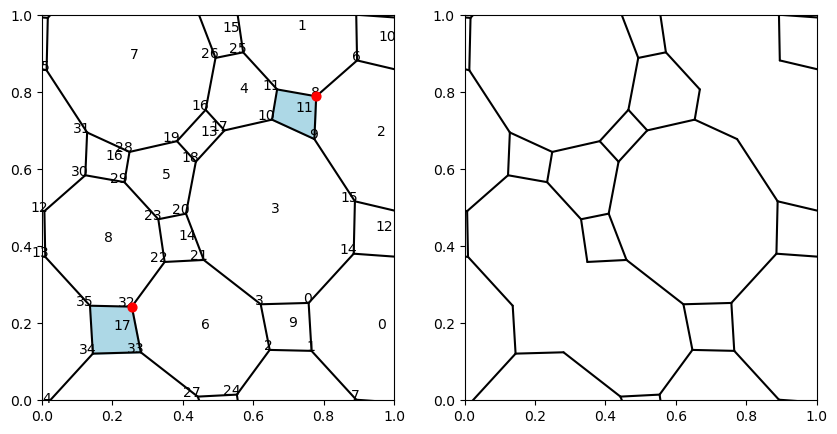

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


reduced_lattice = gu.remove_vertices(lattice, chosen_vertices)

pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(reduced_lattice, ax=ax[1])
pl.plot_plaquettes(
    lattice, subset=chosen_plaquettes, zorder=-10, color_scheme=["lightblue"], ax=ax[0]
)

pl.plot_vertex_indices(lattice, ax=ax[0])
pl.plot_plaquette_indices(lattice, ax=ax[0])

chosen_positions = lattice.vertices.positions[chosen_vertices]
ax[0].scatter(*chosen_positions.T, zorder=10, c="r", s=40)

plt.show()

In [49]:
# brute force dimerisations
dimerisations = gu.dimerise(lattice, -1)
monomer_dimerisations = gu.dimerise(reduced_lattice, -1)
dimer_probabilities = np.average(dimerisations, axis=0)
dimer_dimer_probabilities = np.array(
    [dimer_dimer_prob(dimerisations, c) for c in randomly_chosen_edges]
)
n_dimerisations = dimerisations.shape[0]
n_monomer_dimerisations = monomer_dimerisations.shape[0]

print(f"n_dimers: {n_dimerisations}\n")
print(f"n_monomer_dimerisations: {n_monomer_dimerisations}\n")
print(f"monomer_probabilities: {n_monomer_dimerisations/n_dimerisations}\n")
print(f"dimer_probabilities\n{dimer_probabilities}\n")
print(f"dimer_dimer_probabilities\n{dimer_dimer_probabilities}\n")

n_dimers: 1360

n_monomer_dimerisations: 0

monomer_probabilities: 0.0

dimer_probabilities
[0.20882353 0.19558824 0.18382353 0.20441176 0.20441176 0.19558824
 0.21617647 0.20441176 0.18382353 0.20441176 0.21617647 0.19558824
 0.19705882 0.18382353 0.18382353 0.19705882 0.19558824 0.20882353
 0.39705882 0.39411765 0.41029412 0.40588235 0.40588235 0.41029412
 0.39411765 0.39705882 0.43235294 0.38382353 0.41176471 0.37205882
 0.39411765 0.39705882 0.40588235 0.41029412 0.42205882 0.37352941
 0.42205882 0.37352941 0.38382353 0.43235294 0.37205882 0.41176471
 0.37205882 0.41176471 0.38382353 0.43235294 0.41176471 0.37205882
 0.43235294 0.38382353 0.41029412 0.40588235 0.39705882 0.39411765]

dimer_dimer_probabilities
[0.         0.075      0.05882353 0.02647059 0.08529412 0.03676471
 0.07867647 0.02573529 0.02573529 0.00367647]



First check that the number of dimerisations is right

In [50]:
# compute the four kasteleyn matrices
initial_ujk = ujk_from_fluxes(lattice, np.array([-1] * lattice.n_plaquettes))
orientations = generate_torus_orientations(lattice, initial_ujk)
kasteleyn_matrices = np.array([kasteleyn_matrix(lattice, o) for o in orientations])

# find inverses and pfaffians
inverses = np.array([la.inv(k) for k in kasteleyn_matrices])
pfaffians = np.array([fast_pfaffian_as_mpmath(k) for k in kasteleyn_matrices])


# find n_dimerisations from pfaffian
omega = find_omega(pfaffians)
n_dimerisations_pfaff = int(mpmath.nint(mpmath.fabs(sum(omega * pfaffians) / 2)))
print(n_dimerisations_pfaff)

assert (
    n_dimerisations - n_dimerisations_pfaff == 0
), f"{n_dimerisations - n_dimerisations_pfaff}"
print("counting dimerisations correctly")
# check its all correct
for j, k in enumerate(kasteleyn_matrices):
    assert np.all(k + k.T == 0)

1360
counting dimerisations correctly


In [51]:
# find probabilities per edge
inverse_numerator = np.sum(
    (omega * pfaffians)[:, None, None] * inverses * kasteleyn_matrices, axis=0
)
inverse_denominator = np.sum(omega * pfaffians)
probs_k = np.abs(
    (inverse_numerator / inverse_denominator)[*lattice.edges.indices.T]
).astype(float)


assert np.allclose(probs_k - dimer_probabilities, 0)
print("counting probabilities correctly")

counting probabilities correctly


In [52]:
multi_probabilities = []
for prob, edges in zip(dimer_dimer_probabilities, randomly_chosen_edges):

    verts = lattice.edges.indices[edges]
    kasteleyn_products = np.prod(kasteleyn_matrices[:, *verts.T], axis=1)

    slice = np.ix_(verts.flatten(), verts.flatten())
    inverse_chunk = inverses[:, *slice]
    pfaffians_chunk = np.array([fast_pfaffian_as_mpmath(k) for k in inverse_chunk])
    numerator = np.sum(omega * pfaffians * pfaffians_chunk * kasteleyn_products)

    multi_probabilities.append(np.abs(numerator / inverse_denominator))

assert np.allclose((multi_probabilities - dimer_dimer_probabilities).astype(float), 0)

print("counting dimer-dimer correlations correctly")

counting dimer-dimer correlations correctly


In [ ]:
# compute the four kasteleyn matrices with monomer fluxes
monomer_fluxes = np.array([-1] * lattice.n_plaquettes)
monomer_fluxes[chosen_plaquettes] *= -1
monomer_ujk = ujk_from_fluxes(lattice, monomer_fluxes, initial_ujk)

# make sure this is in the same topological flux sector as the original
changed_edges = monomer_ujk != initial_ujk
x_boundary_edges = np.where(lattice.edges.crossing[:, 0] != 0)[0]
y_boundary_edges = np.where(lattice.edges.crossing[:, 1] != 0)[0]
n_x_changes = np.sum(changed_edges[x_boundary_edges])
n_y_changes = np.sum(changed_edges[y_boundary_edges])
if n_x_changes % 2 != 0:
    monomer_ujk[y_boundary_edges] *= -1
if n_y_changes % 2 != 0:
    monomer_ujk[x_boundary_edges] *= -1


monomer_orientations = generate_torus_orientations(lattice, monomer_ujk)
kasteleyn_tilde_matrices = np.array(
    [kasteleyn_matrix(lattice, o) for o in monomer_orientations]
)


pfaffians_tilde = []
inverses_tilde = []
for k in kasteleyn_tilde_matrices:
    p = fast_pfaffian_as_mpmath(k)
    if abs(p) > 1e-12:
        pfaffians_tilde.append(p)
        inverses_tilde.append(la.inv(k))
    else:
        pfaffians_tilde.append(0)
        inverses_tilde.append(np.zeros_like(k))

pfaffians_tilde = np.array(pfaffians_tilde)
inverses_tilde = np.array(inverses_tilde)
print(pfaffians_tilde)

# find n_dimerisations from pfaffian
omega_tilde = find_omega(pfaffians)

inverses_tilde_restricted = inverses_tilde[:, *np.ix_(chosen_vertices, chosen_vertices)]
inverses_tilde_pfaffs = np.array(
    [fast_pfaffian_as_mpmath(k) for k in inverses_tilde_restricted]
)
monomer_numerator = omega_tilde * inverses_tilde_pfaffs * pfaffians_tilde
n_monomers_pfaff = int(mpmath.nint(mpmath.fabs(sum(monomer_numerator) / 2)))


print(n_monomers_pfaff, n_monomer_dimerisations, "\n\n")
try:
    assert (
        n_monomers_pfaff - n_monomer_dimerisations
    ) == 0, f"{n_monomers_pfaff - n_monomer_dimerisations}"

except AssertionError as e:
    omega_options = np.ones([4, 4]) - 2 * np.eye(4)
    for omega_tilde in omega_options:
        monomer_numerator = omega_tilde * inverses_tilde_pfaffs * pfaffians_tilde
        n_monomers_pfaff = int(mpmath.nint(mpmath.fabs(sum(monomer_numerator) / 2)))
        print(n_monomers_pfaff, n_monomer_dimerisations)

    assert False, f"{n_monomers_pfaff - n_monomer_dimerisations}"

[mpf('-68.000000000000028') mpf('-19.999999999999996')
 mpf('60.000000000000021') mpf('60.000000000000021')]
0 0 




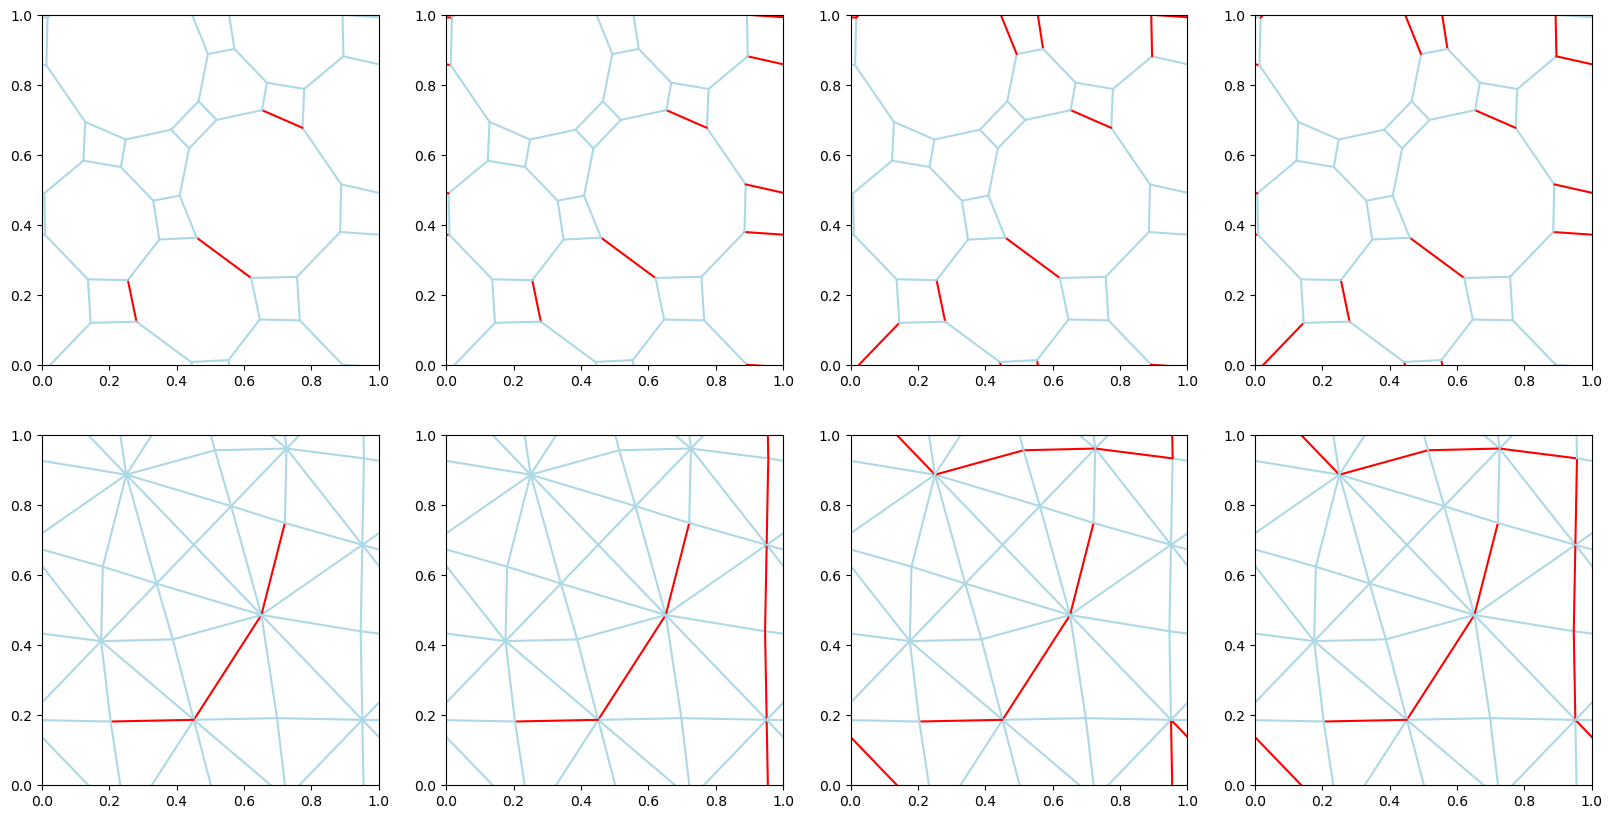

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for ii in range(4):

    ujk_diff = 1 - (monomer_orientations[ii] == initial_ujk)
    pl.plot_edges(
        lattice, ax=ax[0, ii], labels=ujk_diff, color_scheme=["lightblue", "red"]
    )
    pl.plot_edges(
        gu.make_dual(lattice, reg_steps=0),
        ax=ax[1, ii],
        labels=ujk_diff,
        color_scheme=["lightblue", "red"],
    )

In [55]:
del lattice

In [56]:
import pfapack
import pfapack.pfaffian

a = 0
for k in kasteleyn_tilde_matrices:
    a = pfapack.pfaffian.pfaffian(k)
    print(a)

-68.0
-20.000000000000004
60.00000000000001
60.00000000000002
